# Public investment and nearby business engagement
### Exploratory Data Analysis
CIS 509 · Course Project Milestone 2 · Team 4 · September 12, 2026  
John Wheeler (`jwheele4`) · Ryan Wolff (`rwwolff`) · Cameron Anthony (`cantho19`)

> Engagement near Lafitte Greenway and Nashville's Riverfront / Ascend project grew faster than at matched businesses farther away. Stars and sentiment did not improve consistently across the five cases. The results depend on which businesses and geographic areas we compare, and they do not establish causation.

## 1. Project overview
A new park or transit line may bring customers to nearby businesses. We want to know whether Yelp records show that activity, whether customers describe better experiences, and whether the patterns differ across neighborhoods.

We compare business engagement and review experience near five funded projects with farther businesses in the same city. We also compare results by baseline neighborhood income, project type and reported cost.

Our first hypothesis, H1, predicts faster engagement growth near projects. H2 predicts higher stars and sentiment. H3 asks whether the patterns differ by income and project characteristics. We developed these questions during the project, rather than pre-registering confirmatory tests. We report negative results and cases with too few businesses to support a comparison.

Reviews, distinct reviewers, check-ins and tips measure recorded Yelp engagement. They do not verify visits, resident participation, revenue or community welfare. More activity may help a business without benefiting every resident.

## 2. Data sources and study design
We selected five cases with documented footprints, usable opening dates, Yelp coverage and full pre/post years. We selected the three additions before calculating their outcomes. This purposive sample does not represent all public investments.

| Project | Location and intervention | Reported cost and source |
|---|---|---|
| Lafitte Greenway | New Orleans. greenway/public space. opened November 2015 | $9.1 m, [project opening account](https://lafittegreenway.org/blog/lafitte-greenway-opening-friday-november-6/) |
| Sun Link | Tucson. streetcar. opened July 2014 | $196.5 m, [Federal Transit Administration](https://www.transit.dot.gov/about/news/us-department-transportation-celebrates-grand-opening-tucson-streetcar-further-expanding) |
| Dilworth Park | Philadelphia. civic plaza/transit access. opened September 2014 | $55 m, [Center City District](https://centercityphila.org/press-release/dilworth-park-celebrates-10th-anniversary/) |
| Water Works Park | Tampa. park/spring restoration. completed August 2014 | $7.4 m, [funding interviews](https://83degreesmedia.com/waterworks100813/), [city completion account](https://www.tampa.gov/sites/default/files/document/migrated/FY15BudgetBook_part1.pdf) |
| Riverfront Park / Ascend | Nashville. 2015 park addition/performance venue | $52 m, [contemporaneous site-tour report](https://www.nashvillescene.com/music/slideshow-take-a-look-inside-ascend-amphitheater/article_f535a107-e8bc-5138-b3aa-3afb4f7e2ae0.html), [Metro annual report](https://www.nashville.gov/sites/default/files/2021-04/2016AnnualReport-Final_v6_web.pdf) |

These are nominal reported total project costs, not a reconciled series of actual public expenditures. Dilworth combines public/private funding, and its headline cost differs in scope from the [CCD capital ledger](https://files.centercityphila.org/pdf/SOCC2016.pdf). The costs provide context. Five different project/city combinations cannot identify a cost or project-type effect.

| Data source | Records used and collection |
|---|---|
| [Yelp Open Dataset](https://www.yelp.com/dataset) | Local raw archive: business coordinates/categories, dated reviews with stars/text, opaque reviewer IDs, check-in timestamps and dated tips. Businesses within 8 km of each footprint; project-specific complete years within 2008–2019 (Lafitte starts 2010). All business categories and snapshot open/closed statuses retained. |
| [Census ACS five-year estimates](https://www.census.gov/programs-surveys/acs/data/summary-file.html) | Official downloaded summary files: ZIP/ZCTA median household income and poverty. ACS 2011 for Sun Link/Dilworth; ACS 2012 for the others, ending within baseline and before construction. Published uncertainty is retained in the underlying Census extracts. |
| Public GIS and mapped footprints | [Tucson GIS](https://gis.tucsonaz.gov/arcgis/rest/services/PublicMaps/OpenData_Transportation/MapServer/10), [Nashville GIS](https://services2.arcgis.com/HdTo6HJqh92wn4D8/arcgis/rest/services/Park_Boundary_View/FeatureServer/6), current OSM [Dilworth](https://www.openstreetmap.org/way/410095875), [Water Works](https://www.openstreetmap.org/way/190127200), and named Lafitte trail segments. Metric distances use local UTM projections. |
| Project accounts above | Opening dates, construction gaps, intervention type and reported funding/cost scope. These are separate from the broad federal-assistance transactions explored earlier in the project. |


In [1]:
"""Publication-style figures for the five-project EDA; only aggregate inputs are used."""
from pathlib import Path
import textwrap,json
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch,Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
ORDER=['Lafitte','Sun Link','Dilworth Park','Water Works Park','Riverfront / Ascend']
NAMES=['Lafitte Greenway','Sun Link','Dilworth Park','Water Works Park','Riverfront / Ascend']
INK='#20334A';TEAL='#187D8D';ORANGE='#BD623C';GOLD='#D6A744';GRAY='#95A1AC';PALE='#E9EDF0'
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'figure.dpi':140,'savefig.dpi':180,'axes.spines.top':False,'axes.spines.right':False,'axes.spines.left':False,'axes.edgecolor':'#B8C0C8','axes.labelcolor':INK,'text.color':INK,'xtick.color':INK,'ytick.color':INK,'axes.titleweight':'bold','axes.titlesize':11,'figure.facecolor':'white','axes.facecolor':'white'})
def finish(fig,out,name):
 out=Path(out);out.mkdir(exist_ok=True);fig.savefig(out/(name+'.png'),bbox_inches='tight',facecolor='white');fig.savefig(out/(name+'.svg'),bbox_inches='tight',facecolor='white');return fig
def title(fig,headline,subtitle):
 fig.suptitle(headline,x=.02,y=.99,ha='left',fontsize=18,fontweight='bold');fig.text(.02,.90,subtitle,fontsize=10,color='#596876',va='top')
def study_design(reg,out):
 fig,ax=plt.subplots(figsize=(12.7,5.2));fig.subplots_adjust(left=.21,right=.82,top=.78,bottom=.17)
 types=['Greenway / public space','Streetcar / transit','Civic plaza / transit access','Park / spring restoration','Park / performance venue']
 for i,p in enumerate(ORDER):
  r=reg.set_index('project').loc[p];pre=r['pre'];post=r['post'];opening=pd.Timestamp(r.opening);year=opening.year+(opening.dayofyear-1)/365.25
  ax.broken_barh([(pre[0],2)],(i-.14,.28),facecolors=GRAY);ax.broken_barh([(max(pre)+1,min(post)-max(pre)-1)],(i-.14,.28),facecolors=PALE);ax.broken_barh([(post[0],2)],(i-.14,.28),facecolors=TEAL)
  ax.scatter(year,i,marker='D',s=35,color=GOLD,zorder=3);ax.text(2018.38,i-.07,f'${r.cost_millions:g}m',fontsize=12,fontweight='bold',va='center');ax.text(2018.38,i+.18,types[i],fontsize=8.5,va='center',color='#596876')
 ax.set(yticks=range(5),yticklabels=[f'{NAMES[i]}\n{reg.set_index("project").loc[p,"city"]}' for i,p in enumerate(ORDER)],xlim=(2009.8,2018.1),ylim=(4.6,-.6),xticks=range(2010,2019),xlabel='Calendar year');ax.grid(axis='x',color=PALE);ax.set_axisbelow(True);ax.tick_params(axis='y',length=0,pad=12)
 title(fig,'Project characteristics and observation windows','Each case has two baseline and two follow-up years. Construction and opening gaps are excluded.')
 fig.text(.835,.825,'REPORTED COST / TYPE',fontsize=9,fontweight='bold')
 fig.legend(handles=[Patch(color=GRAY,label='Before construction'),Patch(color=PALE,label='Excluded gap'),Line2D([],[],marker='D',linestyle='',color=GOLD,label='Opening'),Patch(color=TEAL,label='Post-opening')],loc='lower center',ncol=4,frameon=False,bbox_to_anchor=(.47,.01),fontsize=9)
 return finish(fig,out,'01_study_design')
def coverage(overview,quality,support,out):
 z=overview.set_index('project').loc[ORDER].join(quality.set_index('project')[['baseline_near_500']]).join(support.query("radius_m==500 and income_group=='All'").set_index('project')[['matched_pairs']]);fig,ax=plt.subplots(figsize=(12,4.7));fig.subplots_adjust(left=.20,right=.78,top=.77,bottom=.15)
 y=np.arange(5);ax.barh(y,100,color=PALE,height=.6);ax.barh(y,100*z.baseline_near_500/z.listed_500m,color=GOLD,height=.6);ax.barh(y,100*z.matched_pairs/z.listed_500m,color=TEAL,height=.6)
 for i,p in enumerate(ORDER):ax.text(103,i,f'{int(z.loc[p,"matched_pairs"]):,} / {int(z.loc[p,"listed_500m"]):,}',va='center',fontsize=11,fontweight='bold',color=ORANGE if p=='Water Works Park' else INK)
 ax.set(yticks=y,yticklabels=NAMES,xlim=(0,100),ylim=(4.6,-.6),xticks=[0,25,50,75,100],xlabel='Share of nearby listings (%)');ax.tick_params(axis='y',length=0);title(fig,'Business coverage and matched samples','Four cases support the primary comparison. Water Works has only two matched businesses.')
 fig.text(.80,.81,'MATCHED / LISTED',fontsize=9,fontweight='bold');fig.legend(handles=[Patch(color=TEAL,label='Matched'),Patch(color=GOLD,label='Baseline ≥5, unmatched'),Patch(color=PALE,label='Fewer than 5 baseline reviews')],loc='lower center',ncol=3,frameon=False,bbox_to_anchor=(.52,-.02),fontsize=9)
 return finish(fig,out,'02_coverage')
def text_diagnostics(cm,length,out):
 fig,axes=plt.subplots(1,2,figsize=(12.8,5.1),gridspec_kw={'width_ratios':[1,1.3]});fig.subplots_adjust(left=.09,right=.96,bottom=.19,top=.75,wspace=.65)
 z=cm.groupby(['stars','vader_label']).reviews.sum().unstack(fill_value=0).reindex(index=[1,2,3,4,5],columns=['Negative','Neutral','Positive']);pct=100*z.div(z.sum(axis=1),axis=0);ax=axes[0];ax.imshow(pct,cmap='Blues',vmin=0,vmax=100,aspect='auto')
 for i in range(5):
  for j in range(3):ax.text(j,i,f'{pct.iloc[i,j]:.1f}%',ha='center',va='center',color='white' if pct.iloc[i,j]>60 else INK,fontweight='bold')
 ax.set(xticks=range(3),xticklabels=pct.columns,yticks=range(5),yticklabels=[f'{i} star'+('' if i==1 else 's') for i in range(1,6)],title='VADER labels within each star rating',xlabel='Whole-review sentiment label');ax.tick_params(length=0)
 ax=axes[1];z=length.set_index('project').loc[ORDER];y=np.arange(5);ax.hlines(y,z.p10_words,z.p90_words,color=GRAY,lw=3);ax.scatter(z.median_words,y,color=TEAL,s=50,zorder=3)
 for i,row in enumerate(z.itertuples()):ax.text(row.p90_words+7,i,str(int(row.median_words))+' median',va='center',fontsize=9)
 ax.set(yticks=y,yticklabels=NAMES,ylim=(4.5,-.5),xlim=(0,340),title='Review length by project',xlabel='Words per review');ax.tick_params(axis='y',length=0);ax.grid(axis='x',color=PALE)
 title(fig,'VADER sentiment and review length','All pre/post review text within 500 m. Star labels provide an imperfect check on VADER sentiment.')
 fig.text(.57,.04,'Line: 10th–90th percentile   •   Dot: median',fontsize=9,color='#596876')
 return finish(fig,out,'03_text_diagnostics')
def outcome_panel(activity,experience,out):
 fig,axes=plt.subplots(1,5,figsize=(15.3,5.2));fig.subplots_adjust(left=.16,right=.985,top=.73,bottom=.16,wspace=.25)
 specs=[('reviews','Review activity','Relative growth (%)',(-55,165)),('checkins','Check-ins','Relative growth (%)',(-55,190)),('tips','Tips','Relative growth (%)',(-60,180)),('stars','Stars','Change contrast (stars)',(-.13,.08)),('compound','VADER','Change contrast (compound)',(-.075,.06))]
 for ax,(metric,heading,xlabel,limits) in zip(axes,specs):
  z=activity.query("radius_m==500 and income_group=='All' and window=='Main'") if metric in ['reviews','checkins','tips'] else experience.query("radius_m==500 and income_group=='All'");z=z[z.metric.eq(metric)].set_index('project').reindex(ORDER);vcol='relative_growth_pct' if metric in ['reviews','checkins','tips'] else 'contrast'
  for i,p in enumerate(ORDER):
   val=z.at[p,vcol];n=z.at[p,'pairs']
   if n<20:ax.axhspan(i-.35,i+.35,color='#F3F4F5');ax.text(sum(limits)/2,i,'Sparse: n=2',ha='center',va='center',fontsize=8,color='#77828C');continue
   color=TEAL if val>=0 else ORANGE;ax.hlines(i,0,val,color=color,lw=2);ax.scatter(val,i,s=48,color=color,zorder=3);label=f'{val:+.1f}' if metric in ['reviews','checkins','tips'] else f'{val:+.3f}';ax.annotate(label,(val,i),xytext=(5 if val>=0 else -5,0),textcoords='offset points',ha='left' if val>=0 else 'right',va='center',fontsize=8)
  ax.axvline(0,color='#9AA5AF',lw=.8);ax.set(xlim=limits,ylim=(4.6,-.6),yticks=range(5),yticklabels=NAMES if ax==axes[0] else [],title=heading,xlabel=xlabel);ax.tick_params(axis='y',length=0);ax.tick_params(axis='x',labelsize=8);ax.xaxis.set_major_locator(plt.MaxNLocator(3));ax.grid(axis='y',color=PALE,zorder=0)
 title(fig,'Matched changes in engagement and review experience','Matched businesses within 500 m versus farther controls. Positive values favor nearby businesses. The estimates are descriptive.')
 fig.text(.16,.025,'Activity cohorts: 142 / 149 / 498 / 2 / 85 pairs.   Experience cohorts: 59 / 75 / 248 / 2 / 45 pairs, in project order.',fontsize=9,color='#596876')
 return finish(fig,out,'04_outcomes')
def income_panel(activity,support,out):
 fig,ax=plt.subplots(figsize=(11,5));fig.subplots_adjust(left=.24,right=.9,top=.75,bottom=.15);groups=['Lower','Middle','Higher'];z=activity.query("radius_m==500 and metric=='reviews' and window=='Main' and income_group!='All'").pivot(index='project',columns='income_group',values='relative_growth_pct').reindex(index=ORDER,columns=groups);n=support.query("radius_m==500 and income_group!='All'").pivot(index='project',columns='income_group',values='matched_pairs').reindex(index=ORDER,columns=groups);masked=z.mask(n<20)
 im=ax.imshow(masked,cmap='BrBG',norm=TwoSlopeNorm(vmin=-200,vcenter=0,vmax=200),aspect='auto')
 for i in range(5):
  for j in range(3):
   count=int(n.iloc[i,j]);value=z.iloc[i,j]
   if count<20:ax.add_patch(Rectangle((j-.5,i-.5),1,1,facecolor='#EEF0F2',edgecolor='white'));text='No pairs' if count==0 else f'Sparse\nn={count}';color='#78838E'
   else:text=f'{value:+.1f}%\nn={count}';color='white' if abs(value)>130 else INK
   ax.text(j,i,text,ha='center',va='center',color=color,fontsize=10)
 ax.set(xticks=range(3),xticklabels=['Lower local ZIP income','Middle local ZIP income','Higher local ZIP income'],yticks=range(5),yticklabels=NAMES);ax.tick_params(length=0);fig.colorbar(im,ax=ax,fraction=.045,pad=.025,label='Relative review growth (%)',ticks=[-200,-100,0,100,200]);title(fig,'Relative review growth by neighborhood income','Baseline ACS income at the business ZIP. Each city has its own income bands. Reviewer incomes are unknown.')
 return finish(fig,out,'05_income')
def sensitivity(activity,influence,out):
 fig,axes=plt.subplots(1,5,figsize=(14,4.5),sharey=True);fig.subplots_adjust(left=.07,right=.98,top=.73,bottom=.18,wspace=.20)
 z=activity.query("income_group=='All' and metric=='reviews' and window=='Main'")
 for ax,p,name in zip(axes,ORDER,NAMES):
  q=z[z.project.eq(p)].sort_values('radius_m');q=q.copy();q.loc[q.pairs<20,'relative_growth_pct']=np.nan;ax.plot(q.radius_m,q.relative_growth_pct,color=GRAY,lw=1.8,marker='o',markersize=5)
  primary=q[q.radius_m.eq(500)]
  if primary.pairs.iloc[0]>=20:ax.scatter(500,primary.relative_growth_pct.iloc[0],color=TEAL,s=65,zorder=3)
  else:ax.text(.5,.8,'250 m / 500 m\nsamples too small',transform=ax.transAxes,ha='center',fontsize=9,color='#75828E')
  ax.axhline(0,color='#A7B0B8',lw=.8);ax.set(title=name,xticks=[250,500,1000],xlim=(175,1075),ylim=(-65,190),xlabel='Radius (m)');ax.tick_params(axis='x',labelsize=9);ax.grid(axis='y',color=PALE)
 axes[0].set_ylabel('Relative review growth (%)');title(fig,'Relative review growth by distance from project','Dots compare 250 m, 500 m and 1,000 m definitions. Teal marks the primary estimate. These are sensitivity checks.')
 return finish(fig,out,'06_sensitivity')
def topic_panel(topics,out):
 cats=['Food and dishes','Location/local identity (mixed)','Mixed evaluations/negation','Mixed interactions/intentions','Overall experience/service','Visit timing/waiting'];short=['Food /\ndishes','Local\nidentity\n(mixed)','Evaluation\n/ negation\n(mixed)','Interaction\n/ intention\n(mixed)','Experience\n/ service','Visit timing\n/ waiting']
 fig,axes=plt.subplots(1,2,figsize=(14,5.2));fig.subplots_adjust(left=.15,right=.98,top=.72,bottom=.23,wspace=.23)
 for ax,metric,heading,limit in zip(axes,['vader','stars'],['Category sentence sentiment','Associated whole-review stars'],[.10,.35]):
  z=topics[topics.area.eq('near')].pivot(index='project',columns=['period','category'],values=metric);delta=(z['post']-z['pre']).reindex(index=ORDER,columns=cats);im=ax.imshow(delta,cmap='BrBG',norm=TwoSlopeNorm(vmin=-limit,vcenter=0,vmax=limit),aspect='auto')
  for i in range(5):
   for j in range(6):
    v=delta.iloc[i,j]
    if pd.isna(v):ax.add_patch(Rectangle((j-.5,i-.5),1,1,facecolor='#EEF0F2',edgecolor='white'));label='—';color='#86909B'
    else:label=f'{v:+.2f}';color='white' if abs(v)>.65*limit else INK
    ax.text(j,i,label,ha='center',va='center',fontsize=8,color=color)
  ax.set(xticks=range(6),xticklabels=short,yticks=range(5),yticklabels=NAMES if ax==axes[0] else [],title=heading);ax.tick_params(length=0,labelsize=8);fig.colorbar(im,ax=ax,fraction=.035,pad=.025,shrink=.75)
 title(fig,'Sentiment and ratings by review category','Post minus pre means for sampled nearby reviews. Business mix may explain differences. Gray cells lack 30 reviews in a period.')
 fig.text(.15,.07,'A review can discuss several categories. Sentence sentiment and whole-review stars measure different things.\nThe model uses the original two cities\' baseline text. We freeze it for all five cases.',fontsize=9,color='#596876')
 return finish(fig,out,'07_topics')
def sun_panel(composition,scopes,out):
 fig,axes=plt.subplots(1,2,figsize=(12.8,5.2),gridspec_kw={'width_ratios':[1,1.25]});fig.subplots_adjust(left=.08,right=.97,top=.74,bottom=.22,wspace=.6)
 ax=axes[0];bottom=np.zeros(2);colors=[INK,GRAY,GOLD];groups=['5+ baseline reviews','1–4 baseline reviews','No baseline reviews'];labels=['5+ baseline reviews','1–4 baseline reviews','No baseline reviews']
 for group,color,label in zip(groups,colors,labels):
  z=composition.set_index('baseline_group').loc[group];v=np.array([z.baseline_reviews,z.post_reviews]);ax.bar([0,1],v,bottom=bottom,width=.55,color=color,label=label)
  if group=='No baseline reviews':ax.text(1,bottom[1]+v[1]/2,'49.4%\nof post reviews',ha='center',va='center',color=INK,fontweight='bold',fontsize=10)
  bottom+=v
 for i,v in enumerate(bottom):ax.text(i,v+250,f'{int(v):,}',ha='center',fontweight='bold')
 ax.set(xticks=[0,1],xticklabels=['2010–11\nBaseline','2015–16\nPost-opening'],ylabel='Recorded corridor reviews',ylim=(0,12500),title='Review counts by baseline activity');ax.legend(loc='upper left',bbox_to_anchor=(-.12,-.18),ncol=1,frameon=False,fontsize=9)
 ax=axes[1];z=scopes.query("radius_m==500 and scope=='All listed businesses' and period=='post'").set_index('metric');metrics=['reviews','checkins','tips'];vals=z.loc[metrics,'relative_growth_pct']
 for i,(metric,val) in enumerate(vals.items()):
  color=TEAL if val>=0 else ORANGE;ax.hlines(i,0,val,color=color,lw=3);ax.scatter(val,i,color=color,s=60);ax.annotate(f'{val:+.1f}%',(val,i),xytext=(7 if val>=0 else -7,0),textcoords='offset points',ha='left' if val>=0 else 'right',va='center',fontsize=11,fontweight='bold')
 ax.axvline(0,color='#A7B0B8');ax.set(yticks=[0,1,2],yticklabels=['Reviews','Check-ins','Tips'],ylim=(2.6,-.6),xlim=(-48,15),xlabel='Relative growth versus farther area (%)',title='Relative growth by engagement measure');ax.tick_params(axis='y',length=0);title(fig,'Sun Link corridor engagement and business composition','All 717 Yelp listings within 500 m of the route. This unmatched comparison includes listings with no baseline reviews.')
 return finish(fig,out,'08_sun_corridor')


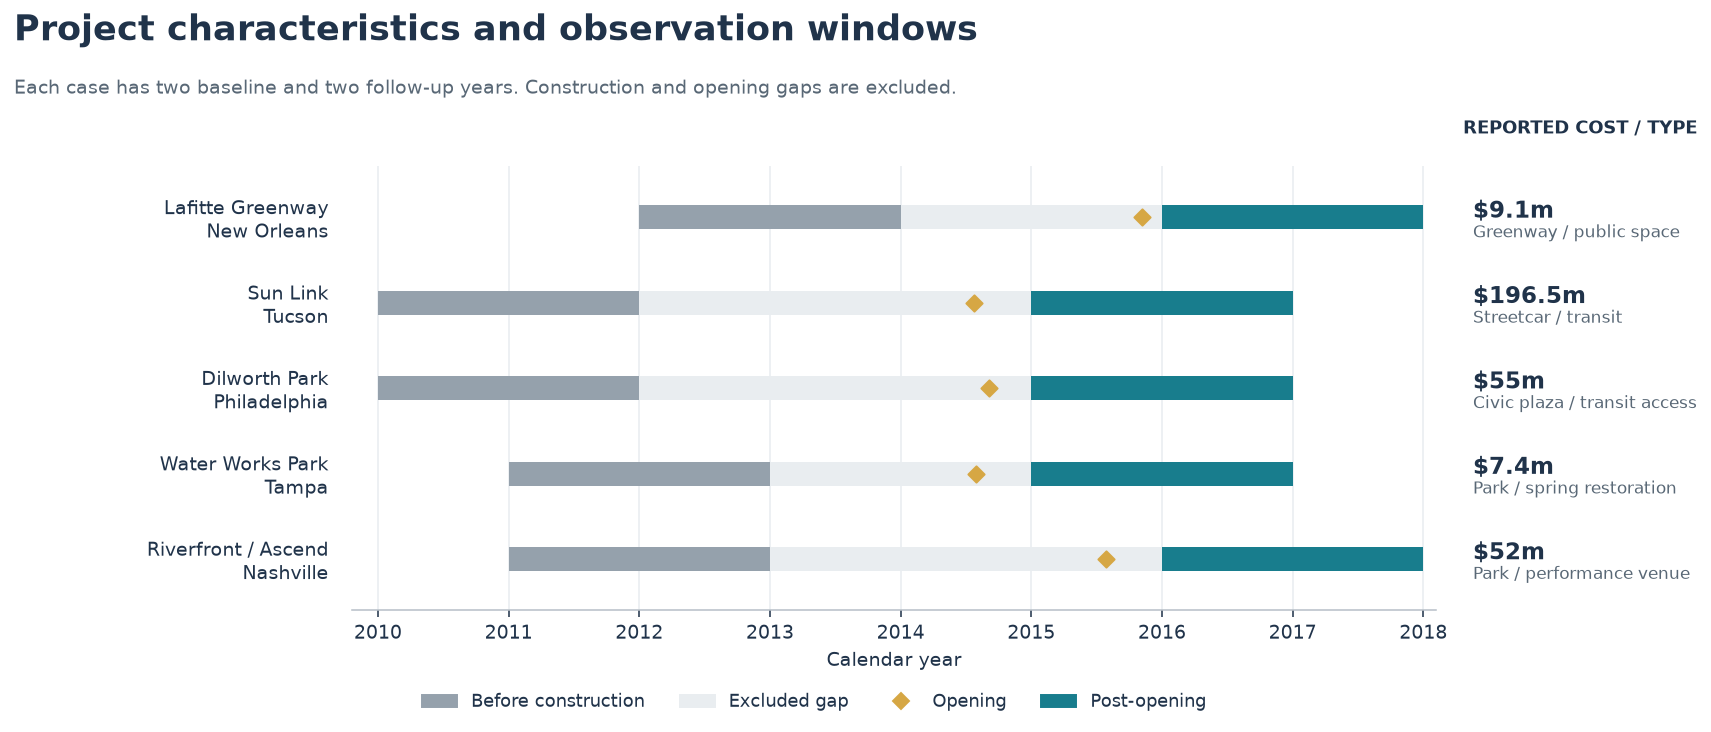

In [2]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from types import SimpleNamespace
viz=SimpleNamespace(ORDER=ORDER,study_design=study_design,coverage=coverage,text_diagnostics=text_diagnostics,
                    outcome_panel=outcome_panel,income_panel=income_panel,sensitivity=sensitivity,
                    topic_panel=topic_panel,sun_panel=sun_panel)

BASE=Path.cwd(); DATA=BASE/'study_data'; FIGURES=BASE/'figures'
# If only the assignment notebook is supplied, restore its embedded aggregate inputs.
# These are the same audited tables, not synthetic data or individual reviews.
if not DATA.exists():
    embedded=json.loads((BASE/'ProjectEDA_Team4.ipynb').read_text())['metadata']['aggregate_inputs']
    DATA.mkdir()
    for filename,content in embedded.items():
        assert Path(filename).name==filename
        (DATA/filename).write_text(content)
read=lambda name: pd.read_csv(DATA/name)
registry=pd.DataFrame(json.loads((DATA/'project_registry.json').read_text()))
activity=read('engagement.csv'); experience=read('experience.csv')
support=read('support.csv'); quality=read('quality.csv')
text_overview=read('text_overview.csv'); influence=read('influence.csv')
# Verify the compact aggregate inputs against the recorded manifest.
provenance=json.loads((DATA/'provenance.json').read_text())
assert all(hashlib.sha256((DATA/f).read_bytes()).hexdigest()==h
           for f,h in provenance['files'].items())
assert set(registry.project)==set(viz.ORDER)
def table(df, caption=None):
    if caption: display(HTML('<p class="table-caption">'+caption+'</p>'))
    display(HTML(df.to_html(index=False, border=0, na_rep='—', classes='eda-table')))
def figure(fig):
    plt.show(); plt.close(fig)
figure(viz.study_design(registry, FIGURES))


Figure 1 compares two full baseline years with two full years after opening. We exclude the gap between them to keep construction and operation separate. The opening marker does not imply an immediate effect.

The primary analysis defines nearby businesses as those within 500 m of the project footprint. Controls are in the same city, more than 1.5 km and up to 8 km away. We repeat the comparison at 250 m and 1,000 m.

A baseline business needs at least five reviews and complete matching covariates. We match it to a business in the same coarse category and baseline ZIP-income band. Matching uses standardized log baseline reviews, baseline VADER, log ZIP income and poverty rate. A control can match more than one nearby business. Matching uses no post-period activity, and businesses with zero post-period activity stay in the engagement analysis.

This comparison describes associations. Section 5.5 uses all nearby Sun Link listings to examine area activity and changes in the business population.

## 3. Data description and summary statistics
The five original geographic extracts contain 2,004,265 review records, including 704,025 in the chosen pre/post windows. The text diagnostics below use all 97,896 nearby pre/post reviews. The full Sun Link audit adds seven nearby listings that the original ZIP/city filters excluded. Its all-business case study contains 717 listings.

| Unit / fields | Type | Meaning |
|---|---|---|
| Business, review and reviewer IDs | String | Link records and de-duplicate; not independent neighborhood observations |
| Date, year and period | Date / categorical | Review/event timing and pre/post assignment |
| Latitude, longitude, distance | Numeric | Current coordinate proximity to the mapped footprint |
| Review text, embedding category | Text / categorical | Language and exploratory discussion category |
| Stars; VADER compound | Ordinal 1–5; numeric −1 to +1 | Whole-review rating and lexicon sentiment |
| Review, reviewer, check-in, tip counts | Nonnegative counts | Recorded activity; different proxies with different coverage |
| ZIP income, poverty and income band | Numeric / categorical | Baseline neighborhood context, not individual reviewer income |
| Reported project cost and type | Numeric / categorical | Case attributes; costs are nominal and scope-dependent |


Project,Businesses ≤8km,Extracted reviews,Pre/post reviews ≤8km,Listings ≤500m,Pre/post reviews ≤500m,Median words,90th percentile words
Lafitte,5827,536263,209125,436,12400,79.0,235.0
Sun Link,5275,205489,64001,710,14722,83.0,235.0
Dilworth Park,10804,743862,250972,1697,53824,91.0,249.0
Water Works Park,4453,219523,74666,75,1233,90.0,246.0
Riverfront / Ascend,4817,299128,105261,308,15717,70.0,207.0


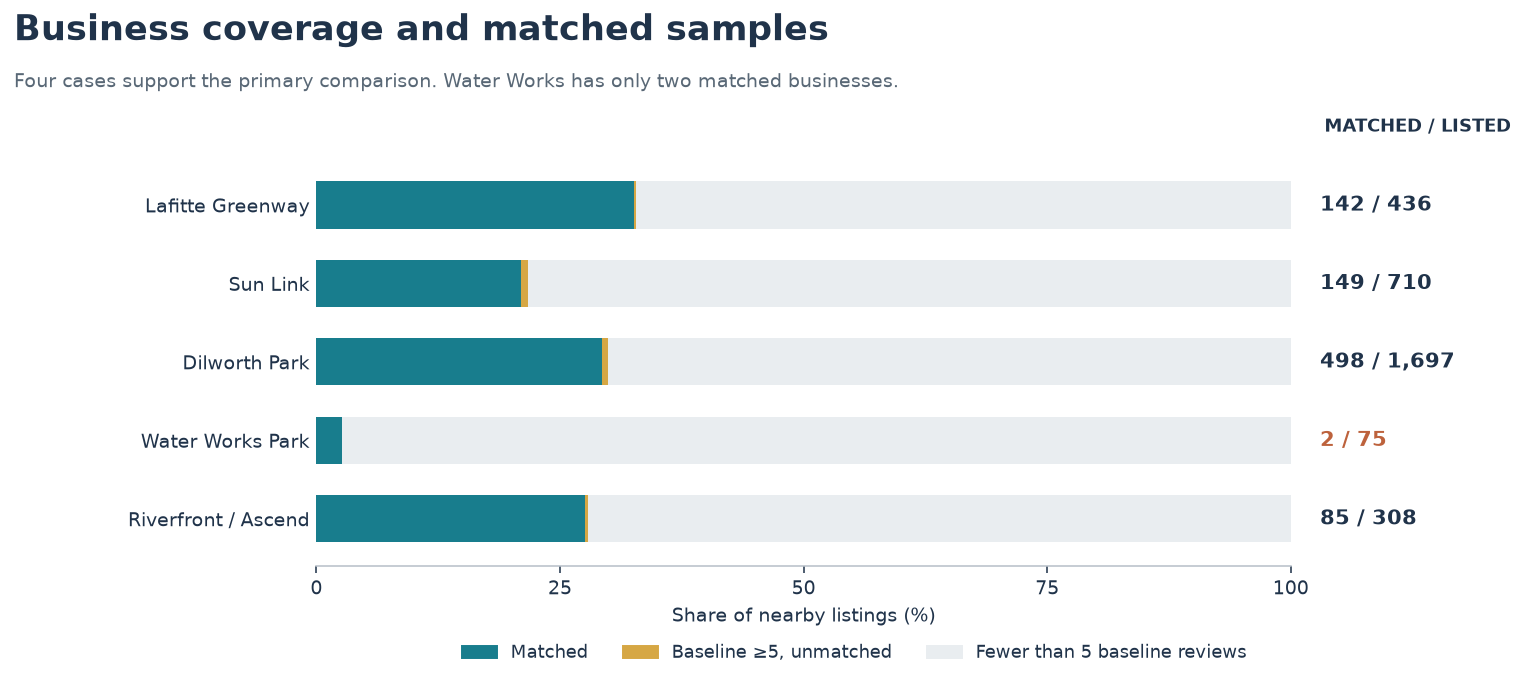

In [3]:
assert int(quality.reviews_extracted.sum())==2_004_265
assert int(quality.reviews_prepost.sum())==704_025
assert int(text_overview.reviews_500m.sum())==97_896
summary=quality[['project','businesses_8km','reviews_extracted','reviews_prepost']].merge(
    text_overview[['project','listed_500m','reviews_500m','median_words','p90_words']],on='project')
summary.columns=['Project','Businesses ≤8km','Extracted reviews','Pre/post reviews ≤8km',
                 'Listings ≤500m','Pre/post reviews ≤500m','Median words','90th percentile words']
table(summary.round(0))
figure(viz.coverage(text_overview, quality, support, FIGURES))


Figure 2 shows how baseline activity and matching reduce the sample. Water Works has 75 nearby listings but only two matched baseline businesses, so we suppress its primary estimate. At 1,000 m it has 23 pairs, all in the higher local-income band.

### Text quality and VADER validation
We score raw text with VADER and retain negation and punctuation. Compound scores at or below −0.05 are negative, and scores at or above +0.05 are positive. Scores between those cutoffs are neutral. We remove stop words only for embeddings and descriptive terms. [VADER method and implementation](https://github.com/cjhutto/vaderSentiment)

Stars provide an imperfect check on sentiment labels. Following Cameron's review, we compare VADER with an always-positive baseline and inspect errors among low-star reviews.

Diagnostic,Value
Reviews with 1–2 or 4–5 stars,"85,320"
Always-positive accuracy,79.7%
VADER accuracy (neutral counts as incorrect),86.7%
Negative-class recall,43.8%
Low-star reviews labeled positive,53.6%


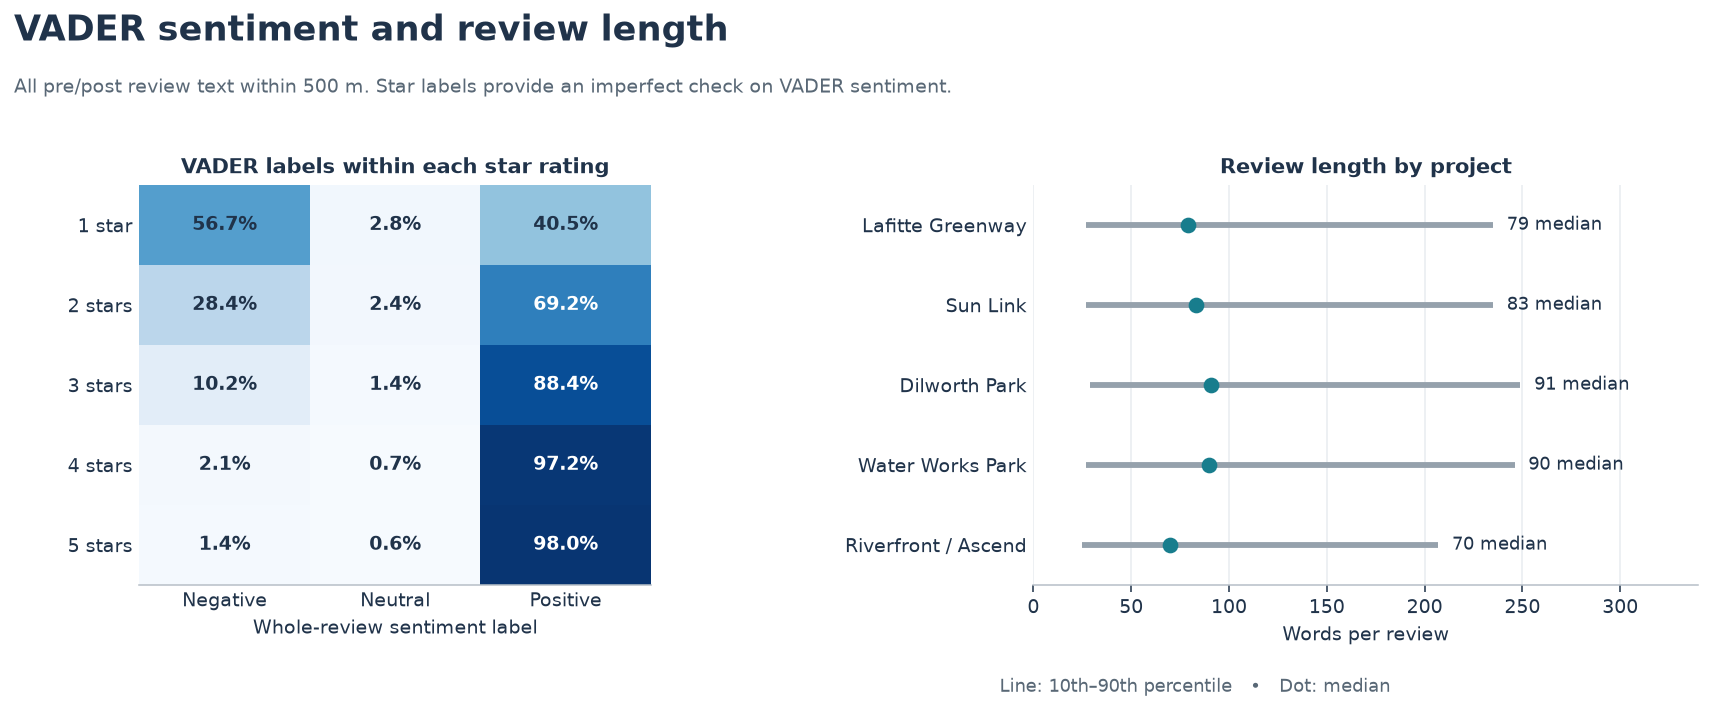

In [4]:
cm=read('vader_star_counts.csv')
binary=cm[cm.stars.ne(3)]  # Exclude three stars only for this weak-label check.
total=binary.reviews.sum()
majority=binary[binary.stars.ge(4)].reviews.sum()/total
correct=binary[(binary.stars.ge(4)&binary.vader_label.eq('Positive')) |
               (binary.stars.le(2)&binary.vader_label.eq('Negative'))].reviews.sum()/total
low=binary[binary.stars.le(2)]
negative_recall=low[low.vader_label.eq('Negative')].reviews.sum()/low.reviews.sum()
false_positive=low[low.vader_label.eq('Positive')].reviews.sum()/low.reviews.sum()
table(pd.DataFrame({'Diagnostic':['Reviews with 1–2 or 4–5 stars','Always-positive accuracy',
                                 'VADER accuracy (neutral counts as incorrect)',
                                 'Negative-class recall','Low-star reviews labeled positive'],
                    'Value':[f'{total:,}',f'{majority:.1%}',f'{correct:.1%}',
                             f'{negative_recall:.1%}',f'{false_positive:.1%}']}))
figure(viz.text_diagnostics(cm, text_overview, FIGURES))


Figure 3 shows why accuracy alone is insufficient. VADER reaches 86.7% accuracy against star-based labels, compared with 79.7% for an always-positive classifier. Yet it identifies only 43.8% of low-star reviews as negative and labels 53.6% positive. Complaints may contain positive words or describe mixed experiences. Human labels are needed to determine which disagreements are sentiment errors.

Median review length ranges from 70 to 91 words, with long upper tails. Validation should check whether performance differs by review length.

## 4. Data quality and suitability
The data let us compare recorded engagement and expressed business experience. They cannot prove community improvement or identify a spending threshold.

| Issue | Consequence and response |
|---|---|
| Uneven sample support | We display pair and control counts and suppress main or income estimates with fewer than 20 pairs. This display rule is not a power calculation. |
| Missing economic context | Matching excludes incomplete covariates. The all-business Sun Link analysis retains an Unknown group. The tables below report missingness. |
| Current geometry and postal ZIPs | ZIPs differ from Census ZCTAs, and neither defines a walking catchment. Current coordinates and boundaries may misrepresent historical exposure. Rivers, highways and spillovers can weaken a straight-line distance comparison. |
| Footprint differences | Lafitte maps 3.70 km versus 4.18 km advertised. Water Works maps 3.67 acres versus roughly 5 project acres. Nashville uses the southern Ascend component, 12.53 current acres versus an 11-acre addition, and excludes the older northern park. These historical boundaries need verification. |
| Selection and composition | Yelp users and listings are self-selected. More reviews or first observed reviews cannot verify visits, residency, business births, survival or profit. This archive contains no photos. |
| Residual confounding | Other redevelopment, tourism, business mix and platform adoption may explain changes. Matching adjusts only for recorded baseline covariates. |
| Repeated observations | Controls can be reused, and businesses share ZIP context. Pairs and reviews are not independent. We report no naive significance tests or independent-pair confidence intervals. |
| Cost and population uncertainty | We have not reconciled public outlays with historical catchment populations. We do not calculate spending per resident or allocate budgets to income groups. |

In [5]:
missing=read('missingness.csv')
context=quality[['project','missing_income_businesses','businesses_8km']].copy()
context['Missing income (%)']=100*context.missing_income_businesses/context.businesses_8km
table(context.rename(columns={'project':'Project','missing_income_businesses':'Missing ZIP income',
                              'businesses_8km':'Businesses ≤8km'}).round(2))
field_missing=missing.groupby(['unit','field'],as_index=False)[['records','missing']].sum()
field_missing['Missing (%)']=100*field_missing.missing/field_missing.records
table(field_missing.round(2), 'Missingness after geographic/date selection; zero coordinate missingness reflects filtering.')
cohort=support.query("radius_m==500 and income_group=='All'")[['project','eligible_near','matched_pairs','distinct_controls']]
table(cohort.rename(columns={'project':'Project','eligible_near':'Eligible nearby',
                            'matched_pairs':'Matched businesses','distinct_controls':'Distinct controls'}))


Project,Missing ZIP income,Businesses ≤8km,Missing income (%)
Lafitte,74,5827,1.27
Sun Link,45,5275,0.85
Dilworth Park,148,10804,1.37
Water Works Park,44,4453,0.99
Riverfront / Ascend,75,4817,1.56


unit,field,records,missing,Missing (%)
Businesses within8km,categories,31176,15,0.05
Businesses within8km,latitude,31176,0,0.00
Businesses within8km,longitude,31176,0,0.00
Businesses within8km,postal_code,31176,15,0.05
Near pre/post reviews,compound,97896,0,0.00
Near pre/post reviews,stars,97896,0,0.00
Near pre/post reviews,word_count,97896,0,0.00


Project,Eligible nearby,Matched businesses,Distinct controls
Lafitte,142,142,80
Sun Link,151,149,86
Dilworth Park,498,498,272
Water Works Park,2,2,2
Riverfront / Ascend,85,85,69


## 5. Preliminary exploration
### 5.1 Engagement and customer experience
For activity, we divide mean post-period counts by mean baseline counts in the near and matched groups. We then divide the near growth factor by the matched growth factor, subtract one and multiply by 100. Positive relative growth means faster growth nearby. It is neither a percentage-point difference nor a causal effect.

We count unique reviewers within each business and period. A reviewer can appear at several businesses.

For stars and VADER, we subtract the matched mean change from the near mean change. Both businesses in each pair need at least five reviews in each period. This requirement selects a smaller experience sample using post-period activity. A business with no post reviews contributes zero activity but has no defined post sentiment, so the activity and experience results describe different business populations.

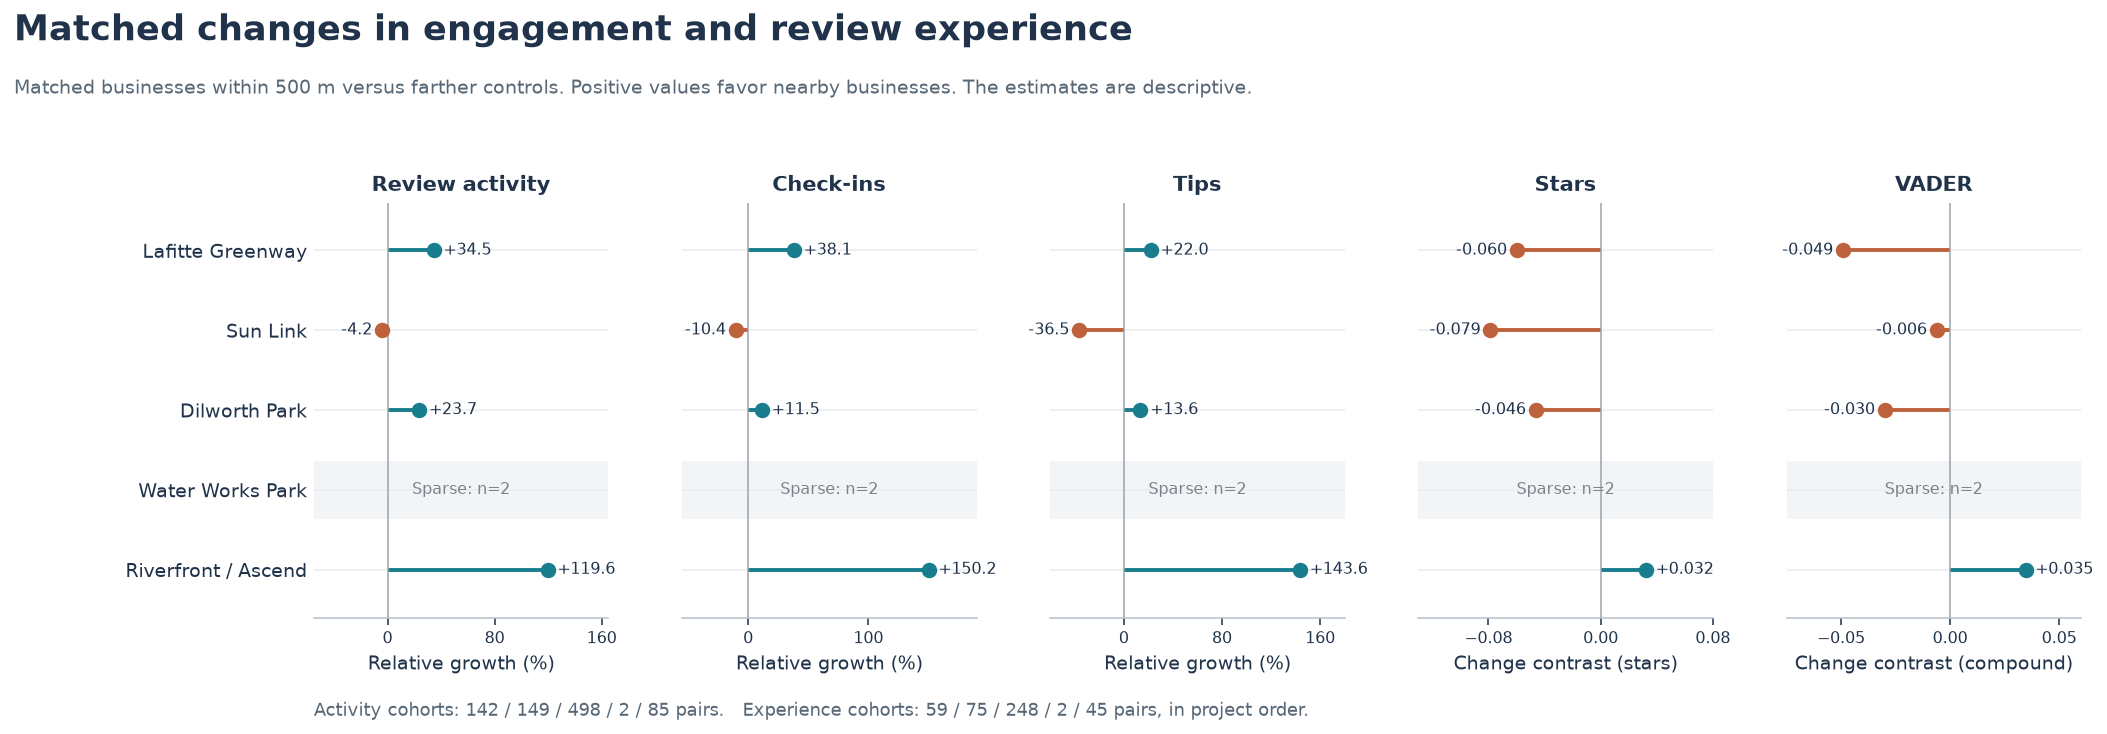

In [6]:
# Recompute the main contrasts from saved mean/count summaries; verify stored results.
valid=(activity.near_pre>0)&(activity.control_pre>0)&(activity.control_post>0)
recomputed=100*((activity.near_post/activity.near_pre)/(activity.control_post/activity.control_pre)-1)
assert np.allclose(recomputed[valid],activity.loc[valid,'relative_growth_pct'],equal_nan=True)
activity['relative_growth_pct']=recomputed.where(valid)
assert np.allclose(experience.near_change-experience.control_change,experience.contrast,equal_nan=True)
experience['contrast']=experience.near_change-experience.control_change
figure(viz.outcome_panel(activity, experience, FIGURES))


Figure 4 shows positive contrasts for reviews, check-ins and tips near Lafitte and Riverfront / Ascend. Sun Link's matched activity contrasts are negative. Dilworth's aggregate engagement is positive, but its result depends on weighting and distance, as Section 5.3 shows.

Only Nashville has positive primary contrasts for both stars and VADER, and the changes are small. H1 has support in some projects. H2 does not hold consistently across them.

Sun Link is the most expensive case and does not have the largest engagement contrast. Several public-space projects have positive results. We cannot isolate a cost or project-type effect, however, because each city has one project and the types largely differ. The costs in Figure 1 provide context. A regression across these five cases would leave that confounding unresolved.

### 5.2 Differences by baseline local income
We divide distinct study ZIPs into three income bands within each city using baseline ACS estimates. We hold the boundaries fixed. These bands are not national income classes or equally populated groups, and they do not describe the incomes of reviewers. Matching uses the same income band and business category.

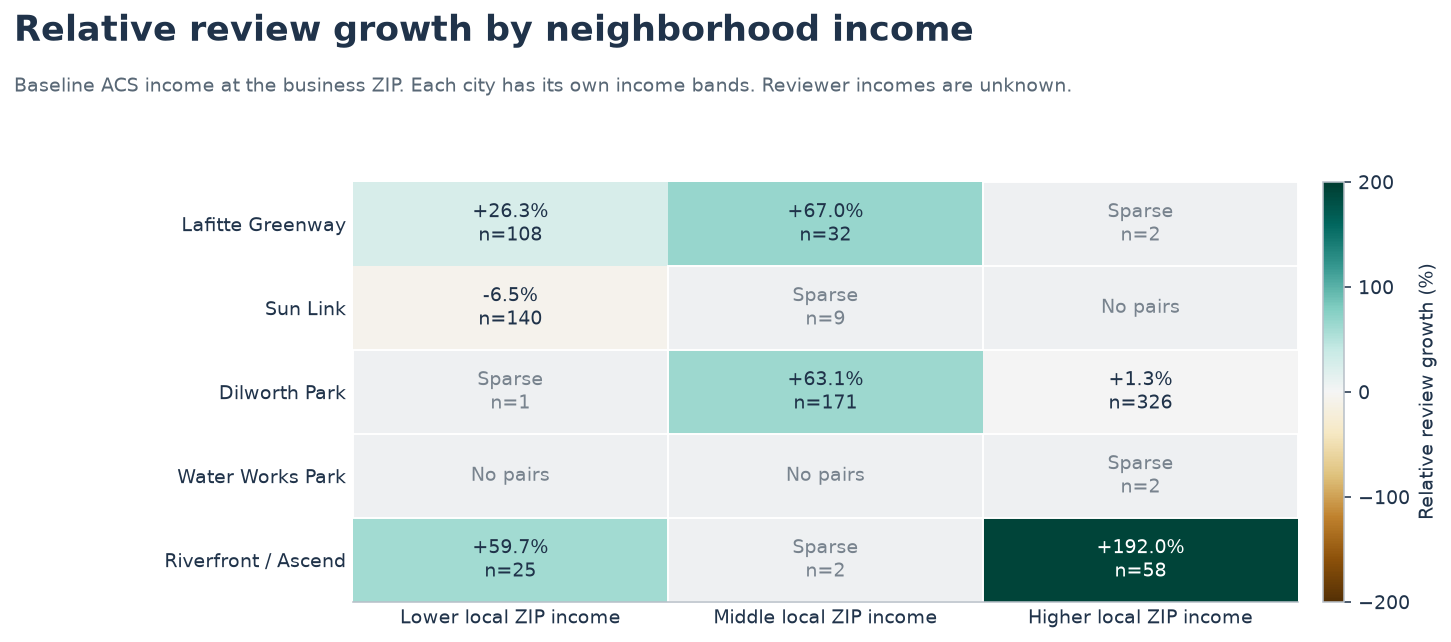

Project,Band,ACS end year,Lower income edge ($),Upper income edge ($),ZIPs
Lafitte,Lower,2012,17300.0,31735.0,6
Lafitte,Middle,2012,31735.0,41456.0,6
Lafitte,Higher,2012,41456.0,71944.0,6
Sun Link,Lower,2011,25350.0,42423.0,10
Sun Link,Middle,2011,42423.0,55904.0,9
Sun Link,Higher,2011,55904.0,83314.0,9
Dilworth Park,Lower,2011,14586.0,31557.0,13
Dilworth Park,Middle,2011,31557.0,45619.0,12
Dilworth Park,Higher,2011,45619.0,93222.0,12
Water Works Park,Lower,2012,26537.0,34317.0,9


In [7]:
figure(viz.income_panel(activity, support, FIGURES))
bands=read('income_bands.csv')
table(bands.rename(columns={'project':'Project','income_group':'Band','acs_year':'ACS end year',
                            'lower_edge':'Lower income edge ($)','upper_edge':'Upper income edge ($)'}).round(0),
      'Fixed local ZIP-income boundaries; ACS five-year estimates have sampling uncertainty.')


Figure 5 shows positive relative review growth in lower-income ZIPs near Lafitte, +26.3%, and Nashville, +59.7%. Sun Link's lower band has a negative contrast of −6.5%. Dilworth has only one lower-band pair. Its supported middle band has a larger contrast than its higher band.

Missing and sparse groups limit the comparison. We cannot conclude that one income group benefits more or calculate spending per resident by income group from these results.

### 5.3 Robustness checks

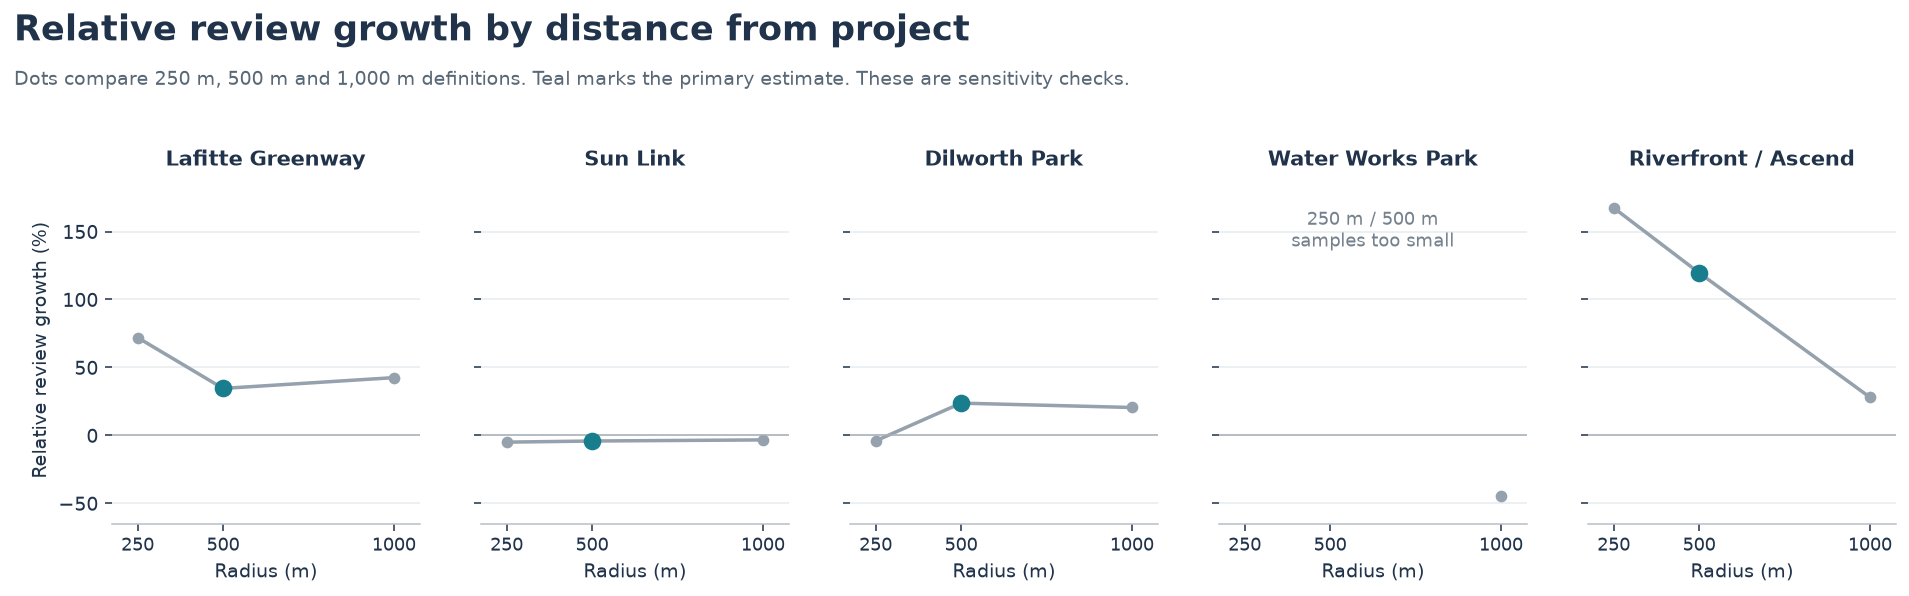

check,project,Full cohort,Match distance <=1,Remove top5% baseline review counts
,Lafitte,34.5,25.6,20.7
,Sun Link,-4.2,-3.3,-15.1
,Dilworth Park,23.7,24.3,5.8
,Water Works Park,—,—,—
,Riverfront / Ascend,119.6,118.9,117.4


project,pairs,relative_growth_pct,log1p_contrast
Lafitte,142,34.535,0.324
Sun Link,149,-4.177,-0.290
Dilworth Park,498,23.702,-0.112
Water Works Park,2,—,—
Riverfront / Ascend,85,119.593,0.519


In [8]:
figure(viz.sensitivity(activity, influence, FIGURES))
checks=influence.query("income_group=='All' and pairs>=20").pivot(
    index='project',columns='check',values='relative_growth_pct').reindex(viz.ORDER)
table(checks.reset_index().round(1), 'Relative review growth (%) after alternative baseline-only inclusion rules.')
weighting=activity.query("radius_m==500 and income_group=='All' and metric=='reviews' and window=='Main'")[
    ['project','pairs','relative_growth_pct','log1p_contrast']].copy()
weighting.loc[weighting.pairs<20,['relative_growth_pct','log1p_contrast']]=np.nan
table(weighting.round(3), 'Aggregate growth and mean paired change in log(1+reviews) weight businesses differently.')


Figure 6 shows how the results change with distance. Lafitte and Nashville remain positive at all three radii, while Sun Link remains negative. Dilworth changes sign at 250 m. At 500 m, its mean log(1+reviews) contrast is negative despite positive aggregate growth. Removing the busiest baseline 5% reduces its aggregate contrast from +23.7% to +5.8%. Dilworth's result therefore depends on the busiest businesses and how we weight them.

Water Works has a −44.8% contrast at 1,000 m with 23 pairs. That wider comparison does not resolve the lack of support for its primary sample.

Matching leaves baseline differences. Lafitte's poverty gap is 0.356 control-pool standard deviations. Earlier-period review contrasts also differ, including about +14.2% for Dilworth. Those diagnostic samples use later baseline activity to select businesses, so they cannot serve as valid causal placebo tests or establish parallel trends. Tourism, private investment and other public improvements remain possible explanations for project differences.

### 5.4 Review categories and sentiment
We use 100-dimensional Word2Vec embeddings, mean non-stopword sentence vectors and six MiniBatchKMeans categories. The original Lafitte/Sun Link baseline model has a 6,966-word vocabulary. We reconstructed its saved categories with 100% agreement, then froze the model for the three new cities. Neither post-period text nor new-city outcomes refit the model.

We sample up to 1,500 reviews for each project, near or comparison area, and pre or post period. The recorded seeds are 509 and 510. The five-case sample contains 28,233 reviews. Sampling fractions differ, and Water Works has only 48 nearby baseline reviews.

Eligible sentences have 4 to 150 alphabetic tokens and at least three in-vocabulary non-stopwords. VADER scores the raw sentence. We average sentiment within each review and category before calculating category means, so long reviews do not receive extra weight within a category. A review can belong to several categories.

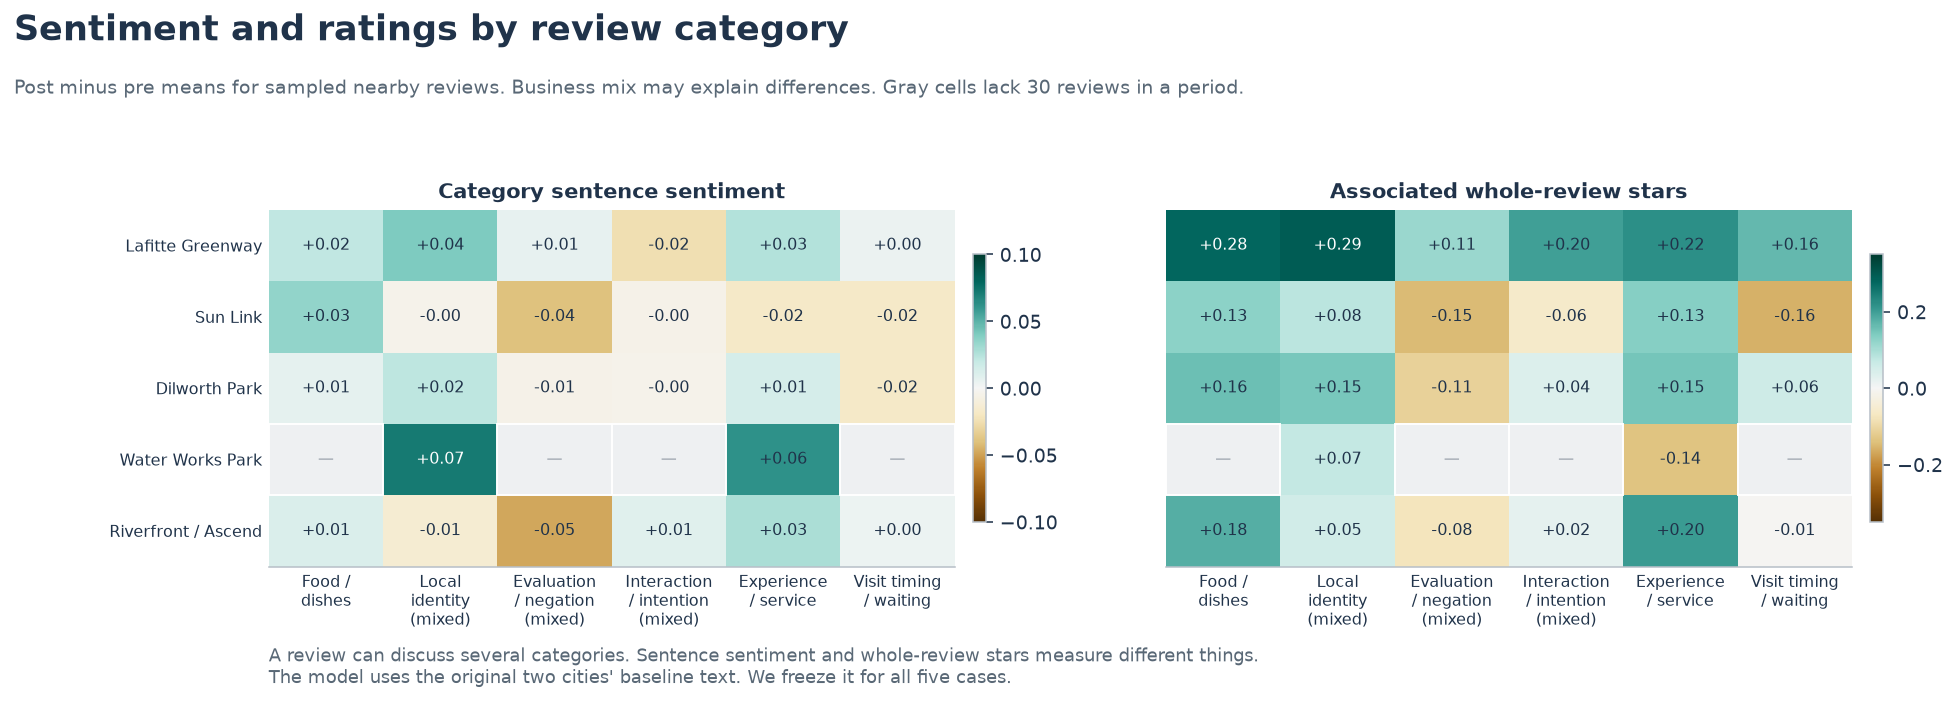

project,period,eligible_sentences,assigned_sentences,assignment_fraction,token_coverage
Dilworth Park,post,21708,19188,0.884,0.912
Dilworth Park,pre,26237,23038,0.878,0.898
Water Works Park,post,21658,18777,0.867,0.910
Water Works Park,pre,12421,10919,0.879,0.903
Riverfront / Ascend,post,20884,17963,0.860,0.916
Riverfront / Ascend,pre,25724,22551,0.877,0.903


project,period,income_group,category,sample_reviews,businesses,vader,stars,sparse
Dilworth Park,post,Higher,Food and dishes,440,154,0.322,3.805,False
Dilworth Park,post,Higher,Location/local identity (mixed),435,213,0.252,3.687,False
Dilworth Park,post,Higher,Mixed evaluations/negation,343,187,0.114,3.324,False
Dilworth Park,post,Higher,Mixed interactions/intentions,443,223,0.219,3.571,False
Dilworth Park,post,Higher,Overall experience/service,577,236,0.444,3.792,False
Dilworth Park,post,Higher,Visit timing/waiting,460,215,0.158,3.502,False
Dilworth Park,post,Lower,Food and dishes,3,2,—,—,True
Dilworth Park,post,Lower,Location/local identity (mixed),2,1,—,—,True
Dilworth Park,post,Lower,Mixed interactions/intentions,1,1,—,—,True
Dilworth Park,post,Lower,Overall experience/service,2,2,—,—,True


project,period,category,assigned_reviews,prevalence_pct
Dilworth Park,post,Location/local identity (mixed),1499,54.6
Dilworth Park,post,Food and dishes,1499,57.6
Dilworth Park,post,Mixed evaluations/negation,1499,41.9
Dilworth Park,post,Overall experience/service,1499,70.9
Dilworth Park,post,Mixed interactions/intentions,1499,54.2
Dilworth Park,post,Visit timing/waiting,1499,55.6
Dilworth Park,pre,Location/local identity (mixed),1494,61.6
Dilworth Park,pre,Food and dishes,1494,58.4
Dilworth Park,pre,Mixed evaluations/negation,1494,45.9
Dilworth Park,pre,Overall experience/service,1494,71.8


In [9]:
sampling=read('topic_sampling.csv');original=json.loads((DATA/'embedding_audit.json').read_text())
transfer=json.loads((DATA/'transfer_audit.json').read_text())
assert int(sampling.sample_reviews.sum())==28_233
assert transfer['baseline_reconstruction_agreement']==1.0
figure(viz.topic_panel(read('topics.csv'), FIGURES))
coverage=read('transfer_coverage.csv')
table(coverage[['project','period','eligible_sentences','assigned_sentences','assignment_fraction','token_coverage']].round(3),
      'Fixed-model transfer coverage in the three added cities.')
# Full category/income summaries remain accessible without overwhelming the report.
income_topics=read('income_topics.csv');near_topics=income_topics[income_topics.area.eq('near')]
display(HTML('<details><summary>Category sentiment and associated stars by baseline income</summary>'+
             near_topics.drop(columns=['area']).round(3).to_html(index=False,na_rep='—')+'</details>'))
prev=read('topic_prevalence.csv');display(HTML('<details><summary>Category prevalence in sampled nearby reviews</summary>'+
    prev[prev.area.eq('near')][['project','period','category','assigned_reviews','prevalence_pct']].round(1).to_html(index=False)+'</details>'))


Figure 7 shows no uniform improvement across review categories. Several clusters mix evaluation, negation and interaction language instead of separating topics. Their labels need human review. Sentiment-bearing words also helped form the clusters, so category and sentiment associations partly depend on the representation. The frozen model assigns about 86% to 88% of eligible sentences in the new cities.

These sampled descriptions do not use the matched business comparison. The stars panel shows whole-review ratings, not aspect ratings. We display a category mean only when each period has at least 30 review/category observations. Reviews can contribute to several categories, so prevalence can sum above 100%. Sampled category counts do not measure population engagement.

### 5.5 Sun Link along the full line
The original geometry covered the full route. We expand the business population by removing baseline-review, original ZIP-list, city-label, category, open-status and Census-completeness filters. This includes 717 Yelp listings within 500 m, from Mercado through downtown to the university. [Official route map](https://www.suntran.com/wp-content/uploads/2021/07/Sun-Link-route-Map.pdf)

Seven added records have missing or inconsistent city or ZIP metadata. We flag them and repeat the comparison without them. These listings are not a census of all operating businesses.

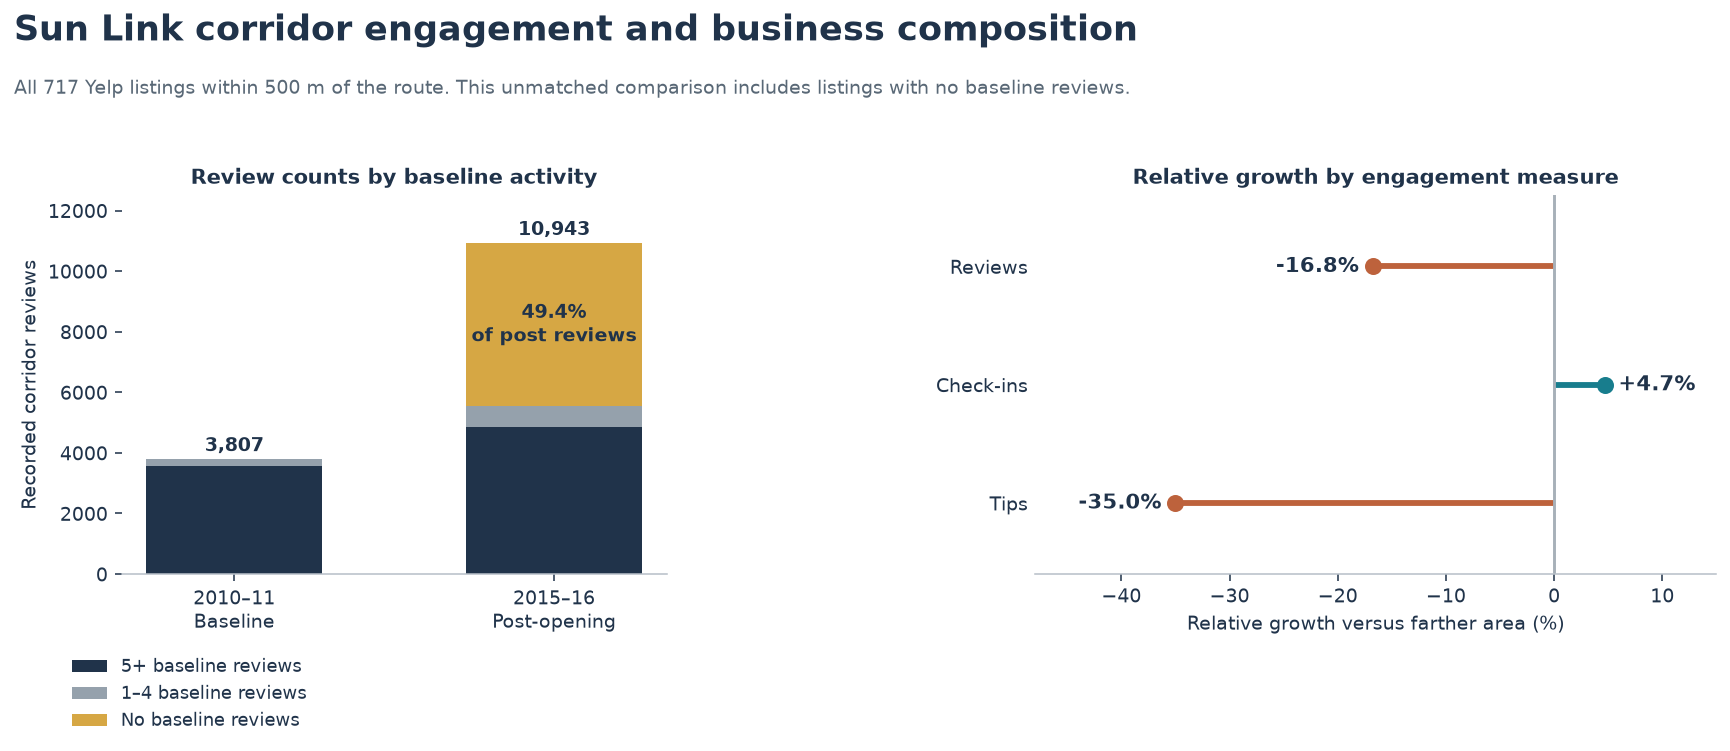

listed_businesses,baseline_reviewed,post_reviewed,no_baseline_reviews,unknown_income,location_flags
717,278,470,439,34,7


Measure,Corridor before,Corridor after,Corridor change,Farther change,Change contrast
compound,0.7575,0.6963,-0.0612,-0.1064,0.0452
stars,3.7757,3.8634,0.0877,-0.0160,0.1037


In [10]:
sun_scopes=read('sun_scopes.csv');sun_composition=read('sun_composition.csv')
figure(viz.sun_panel(sun_composition, sun_scopes, FIGURES))
sun_cov=read('sun_coverage.csv').query('radius_m==500')
table(sun_cov[['listed_businesses','baseline_reviewed','post_reviewed','no_baseline_reviews','unknown_income','location_flags']],
      'Inclusive 500 m corridor coverage; baseline 2010–11 versus post 2015–16.')
sun_exp=read('sun_experience.csv').query('radius_m==500').pivot(index='metric',columns=['area','period'],values='mean')
sun_exp['Near change']=sun_exp[('Near','post')]-sun_exp[('Near','pre')]
sun_exp['Farther change']=sun_exp[('Comparison','post')]-sun_exp[('Comparison','pre')]
sun_exp['Change contrast']=sun_exp['Near change']-sun_exp['Farther change']
sun_table=pd.DataFrame({'Measure':sun_exp.index,'Corridor before':sun_exp[('Near','pre')].values,'Corridor after':sun_exp[('Near','post')].values,'Corridor change':sun_exp['Near change'].values,'Farther change':sun_exp['Farther change'].values,'Change contrast':sun_exp['Change contrast'].values})
table(sun_table.round(4))
display(HTML('<details><summary>Inclusive Sun Link income and all-review topic results</summary>'+
    read('sun_income_support.csv').to_html(index=False)+'<p>Unpaired review-growth comparisons by income</p>'+
    read('sun_income.csv').query("dimension=='income_group' and metric=='reviews'").round(3).to_html(index=False,na_rep='—')+
    '<p>Frozen categories applied to every qualifying pre/post corridor review</p>'+
    read('sun_topics.csv').round(3).to_html(index=False,na_rep='—')+'</details>'))


Figure 8 shows corridor reviews rising from 3,807 to 10,943, a 187.4% increase. Reviewed businesses rise from 278 to 470. Nearly half of post reviews come from businesses with no baseline reviews. That does not establish that the businesses are new.

Farther-area reviews grow 245.4%, leaving a −16.8% relative corridor contrast. Excluding flagged locations gives almost the same result, −16.7%. Check-ins show a +4.7% relative advantage.

Pooled corridor stars rise from 3.776 to 3.863, while VADER falls from 0.758 to 0.696. Farther-area declines are larger, so both relative pooled experience contrasts are positive. Changes in the business and reviewer population may explain these results. They do not establish within-business improvement or overturn the matched comparison.

The full topic extension processes all 14,750 pre/post corridor reviews and assigns 98,723 qualifying sentences with the frozen model. The detail table above contains these results.

## 6. Interpretation and proposed AI solution
Lafitte and Nashville show positive engagement associations. Across the five cases, we find no consistent improvement in sentiment or ratings. We cannot identify a spending threshold or establish who benefits across income groups. H3 remains unresolved where groups have too few businesses to compare.

The next-stage tool should let users inspect each project's activity and experience results alongside its sample support. Our current workflow uses pandas aggregation, text preprocessing, VADER, embeddings, clustering and visual comparison. Before extending it, we need to validate the text measures and exposure definitions.

| Component | Next step and evaluation |
|---|---|
| Review sentiment | Human-label a sample stratified by project, time, stars and length. Compare VADER with TF-IDF and a linear classifier. Consider a pretrained language model if the baseline leaves important errors. Report macro F1 and negative recall on business/time-held-out data. |
| Review categories | Human-audit both coherent and mixed clusters. Measure agreement and category precision/recall, and compare the frozen embeddings with a supervised text baseline. Keep label selection independent of whether a project result is positive. |
| Investment exposure | Verify historical footprints, dates, actual public expenditures and pre-project small-area population. Define a defensible catchment and its resident population before calculating spending per resident. |
| Study design | Add projects within each type, define outcomes and lags before testing, and inspect pre-trends. Uncertainty methods must account for shared controls, ZIPs and projects. Five heterogeneous cases cannot identify causal cost or type effects. |
| Results display | Show activity and experience separately. Include sample coverage, income context and source provenance. Flag sparse comparisons so review growth alone does not determine whether a project appears successful. |

The repository history retains the earlier federal-assistance/ZIP analysis. Cameron's review informed the within-place comparisons, exposure checks and majority-class sentiment baseline. This submission uses documented projects because a federal transaction's recorded ZIP does not define where its benefits occur.

## 7. Reproduction and scope of this deliverable
Run the notebook from its folder with Python 3.11 or 3.12 and `pandas`, `numpy`, `matplotlib`, `nbformat`, `nbclient`, `nbconvert` and `ipykernel`. It contains all figure code and embeds the compact aggregate inputs. If `study_data/` is absent, the first analysis cell restores the tables from notebook metadata. Keep the submitted filename so the cell can locate them.

Each run verifies input hashes, recomputes contrasts and diagnostics, and saves PNG and SVG figures. The companion `eda_visuals.py` mirrors the figure code but is not required to run the notebook. The HTML contains its images and can be read without the supporting files.

Raw extraction, VADER scoring, matching and embedding training are upstream preparation stages. The notebook reproduces the displayed analysis from their aggregates. The local scripts and audits remain in `Five Project Study`, `Sun Link Full Corridor`, the two pilot folders and `Embedding Categories`. `study_data/provenance.json` records preparation sources and hashes, and the README explains the package. The submitted files and aggregate package contain no raw review text or reviewer IDs. The files have not been submitted, and teammate review is not implied.

## 8. Generative AI use
OpenAI Codex assisted with source audits, Census linkage, project selection, Python implementation and debugging, embeddings, matching, diagnostics, figures, notebook execution and writing. Anthropic's Claude assisted Cameron's earlier rubric, sentiment-baseline and robustness review. Those contributions informed this version.

The category labels are provisional and AI-assisted. They have not been validated by humans. All numerical findings come from local data or verified aggregate outputs. The team is responsible for understanding, checking and explaining the code, sources, methods and conclusions.